<a href="https://colab.research.google.com/github/Marchak0915/Facebook-ads-perfomance-analysis-and-visualization/blob/main/Facebook_Ads_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import urllib
file_id = 'C:/Users/FIN-UP/Downloads/facebook_ads_data.csv'
df = pd.read_csv(file_id)
print(df.head())


      ad_date campaign_name  total_spend  total_impressions  total_clicks  \
0  2022-11-05     Expansion         0.00                  0             0   
1  2022-11-01     Expansion         0.00                  0             0   
2  2022-10-31     Expansion       227.45               6054            58   
3  2022-10-30     Expansion       335.91              27562            69   
4  2022-10-29     Expansion       714.03              33358           115   

   total_value   cpc    cpm       ctr      romi  
0         0.00   NaN    NaN       NaN       NaN  
1         0.00   NaN    NaN       NaN       NaN  
2       191.87  3.92  37.57  0.009580  0.843570  
3       472.61  4.87  12.19  0.002503  1.406954  
4       680.34  6.21  21.41  0.003447  0.952817  


In [ ]:
df['ad_date'] = pd.to_datetime(df['ad_date'])
df_2021 = df[df['ad_date'].dt.year == 2021]

print(df_2021.head())



       ad_date campaign_name  total_spend  total_impressions  total_clicks  \
274 2021-12-31     Lookalike       143.19              24699           194   
275 2021-12-31        Trendy         8.82              25345            63   
276 2021-12-31     Wholesale        21.37               6705            24   
277 2021-12-30     Lookalike       227.56              44527           897   
278 2021-12-30        Trendy        31.92               8833            58   

     total_value   cpc   cpm       ctr      romi  
274       138.86  0.74  5.80  0.007855  0.969760  
275        16.32  0.14  0.35  0.002486  1.850340  
276        27.93  0.89  3.19  0.003579  1.306972  
277       243.02  0.25  5.11  0.020145  1.067938  
278        63.67  0.55  3.61  0.006566  1.994674  


In [ ]:
daily_stats=df.groupby('ad_date')[['total_spend', 'total_impressions', 'total_clicks', 'total_value']].sum()

In [ ]:
daily_df = df.groupby('ad_date').sum().reset_index()

In [ ]:
daily_stats_2021 = df_2021.groupby('ad_date').sum()
daily_stats_2021

,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
ad_date,,,,,,,,,
2021-01-01,BrandDiscounts,0.39,353,0,0.59,0.00,1.10,0.000000,1.512821
2021-01-02,Discounts,7.74,10709,205,6.90,0.04,0.72,0.019143,0.891473
2021-01-04,Discounts,70.06,22440,1256,68.47,0.06,3.12,0.055971,0.977305
2021-01-05,Discounts,81.15,60232,1379,61.68,0.06,1.35,0.022895,0.760074
2021-01-06,BrandDiscounts,142.77,65265,431,145.97,0.33,2.77,0.006616,2.022425
...,...,...,...,...,...,...,...,...,...
2021-12-27,LookalikeTrendyWholesale,478.31,103725,504,686.47,2.01,9.31,0.022001,4.236782
2021-12-28,LookalikeTrendyWholesale,359.83,101788,499,450.47,2.20,8.83,0.012031,4.178221
2021-12-29,LookalikeTrendyWholesale,163.25,32290,435,171.76,1.66,13.96,0.040439,3.790408


Text(0.5, 1.0, '1.1. Графік  із щоденною сумою витрат на рекламу у 2021 році')

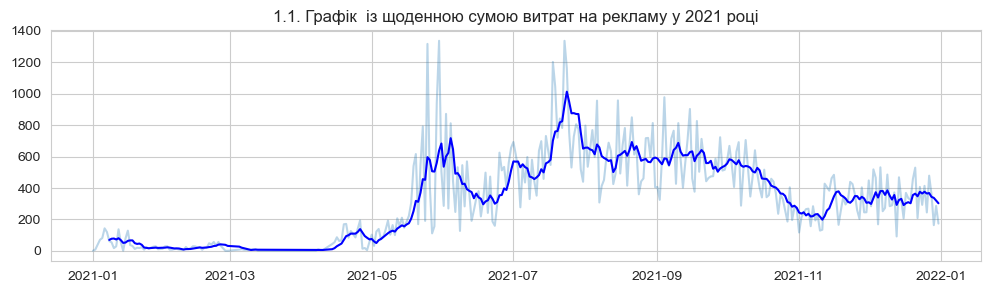

In [ ]:
daily_avg_stats = daily_stats_2021.reset_index()
plt.figure(figsize=(12, 3), dpi=100)
plt.plot(daily_avg_stats['ad_date'], daily_avg_stats['total_spend'], label='Щоденні витрати', alpha=0.3)
plt.plot(daily_avg_stats['ad_date'], daily_avg_stats['total_spend'].rolling(window=7).mean(), label='Рухоме середнє (7 днів)', color='blue')
plt.title('1.1. Графік  із щоденною сумою витрат на рекламу у 2021 році')

In [ ]:
df['ad_date'] = pd.to_datetime(df['ad_date'])
df_2021 = df[df['ad_date'].dt.year == 2021].copy()
df_2021['romi'] = (df_2021['total_value'] - df_2021['total_spend']) / df_2021['total_spend']
daily_romi = df_2021.groupby('ad_date')['romi'].mean()
print(daily_romi.head())


ad_date
2021-01-01    0.512821
2021-01-02   -0.108527
2021-01-04   -0.022695
2021-01-05   -0.239926
2021-01-06    0.011212
Name: romi, dtype: float64


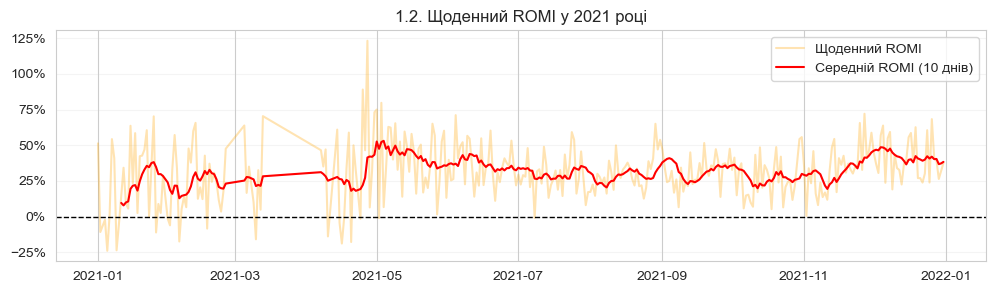

In [ ]:
df_2021 = df_2021[df_2021['total_spend'] > 0].copy()
df_2021['romi'] = (df_2021['total_value'] - df_2021['total_spend']) / df_2021['total_spend']
daily_avg_stats = df_2021.groupby('ad_date')['romi'].mean().reset_index()
plt.figure(figsize=(12, 3), dpi=100)
plt.plot(daily_avg_stats['ad_date'], daily_avg_stats['romi'], label='Щоденний ROMI', alpha=0.3, color='orange')
plt.plot(daily_avg_stats['ad_date'], daily_avg_stats['romi'].rolling(window=10).mean(), label='Середній ROMI (10 днів)', color='red')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('1.2. Щоденний ROMI у 2021 році')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

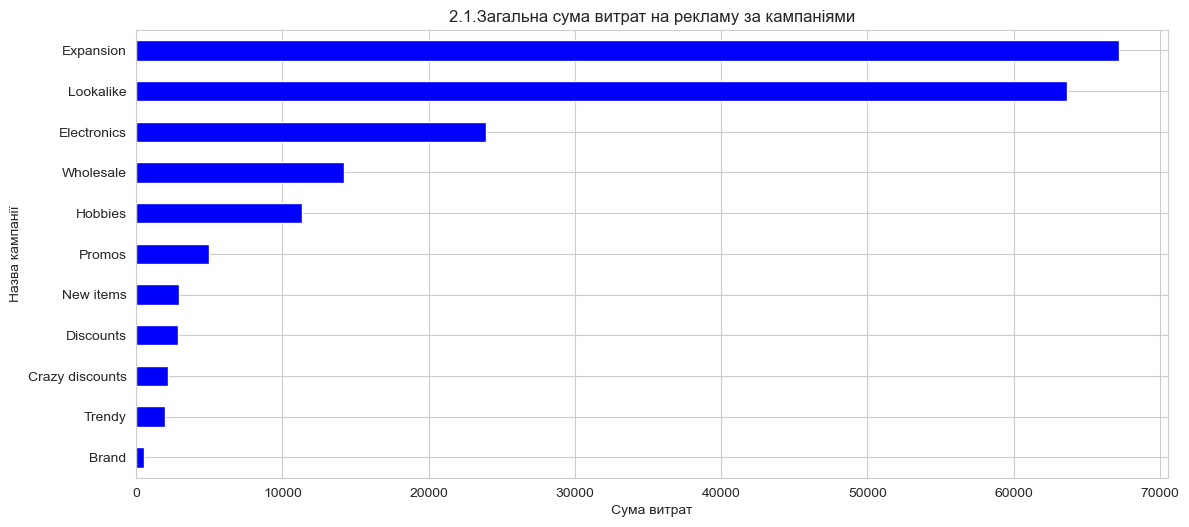

In [ ]:
campaign_stats = df.groupby('campaign_name')[['total_spend', 'total_value']].sum()

campaign_stats['romi'] = ((campaign_stats['total_value'] - campaign_stats['total_spend']) / campaign_stats['total_spend']) * 100
plt.figure(figsize=(12, 10), dpi=100)

plt.subplot(2, 1, 1)
campaign_stats['total_spend'].sort_values().plot(kind='barh', color='blue')
plt.title('2.1.Загальна сума витрат на рекламу за кампаніями')
plt.xlabel('Сума витрат')
plt.ylabel('Назва кампанії')
plt.tight_layout()
plt.show()


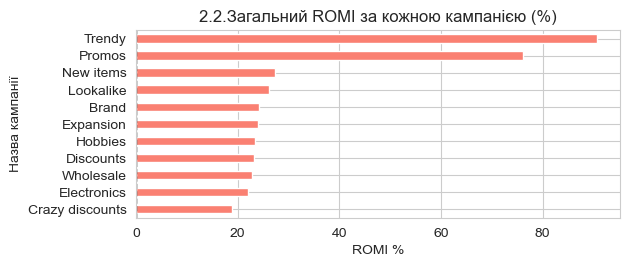

In [ ]:
plt.subplot(2, 1, 2 )
campaign_stats['romi'].sort_values().plot(kind='barh', color='salmon')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('2.2.Загальний ROMI за кожною кампанією (%)')
plt.xlabel('ROMI %')
plt.ylabel('Назва кампанії')

plt.tight_layout()
plt.show()

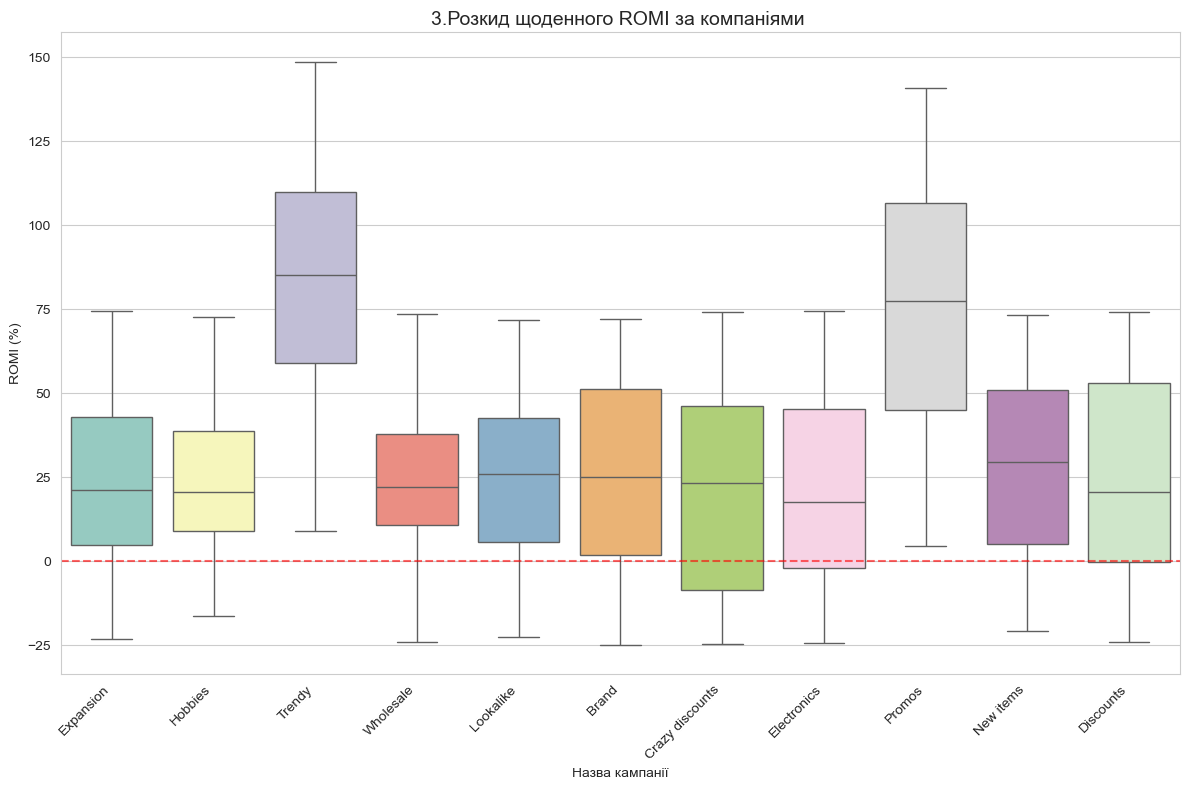

In [ ]:
df['romi'] = ((df['total_value'] - df['total_spend']) / df['total_spend']) * 100
plt.figure(figsize=(12, 8), dpi=100)
sns.boxplot(data=df, x='campaign_name', y='romi',fliersize=8, hue='campaign_name', palette='Set3', legend=False)
plt.title('3.Розкид щоденного ROMI за компаніями ', fontsize=14)
plt.ylabel('ROMI (%)')
plt.xlabel('Назва кампанії')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

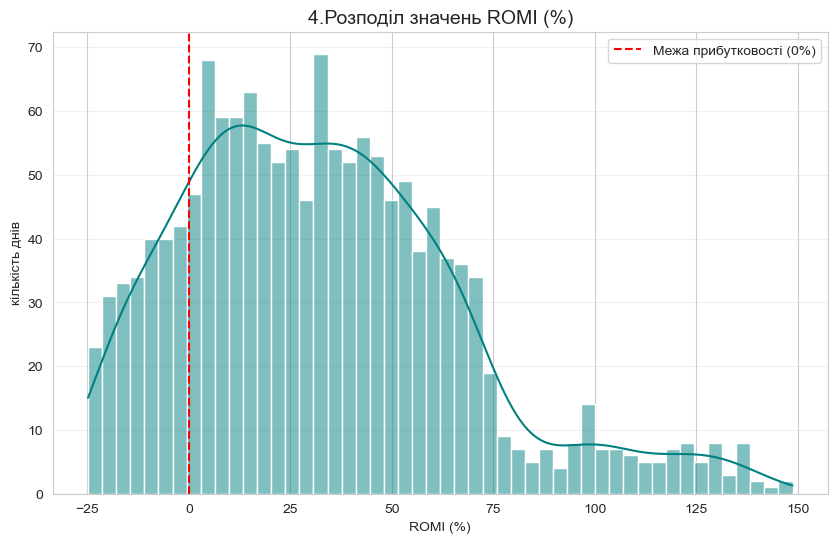

In [ ]:
df = df[df['total_spend'] > 0]
df['romi'] = ((df['total_value'] - df['total_spend']) / df['total_spend']) * 100
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(df['romi'], bins=50, color='teal', kde=True)
plt.title('4.Розподіл значень ROMI (%)', fontsize=14)
plt.xlabel('ROMI (%)')
plt.ylabel('кількість днів')
plt.axvline(0, color='red', linestyle='--', label='Межа прибутковості (0%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

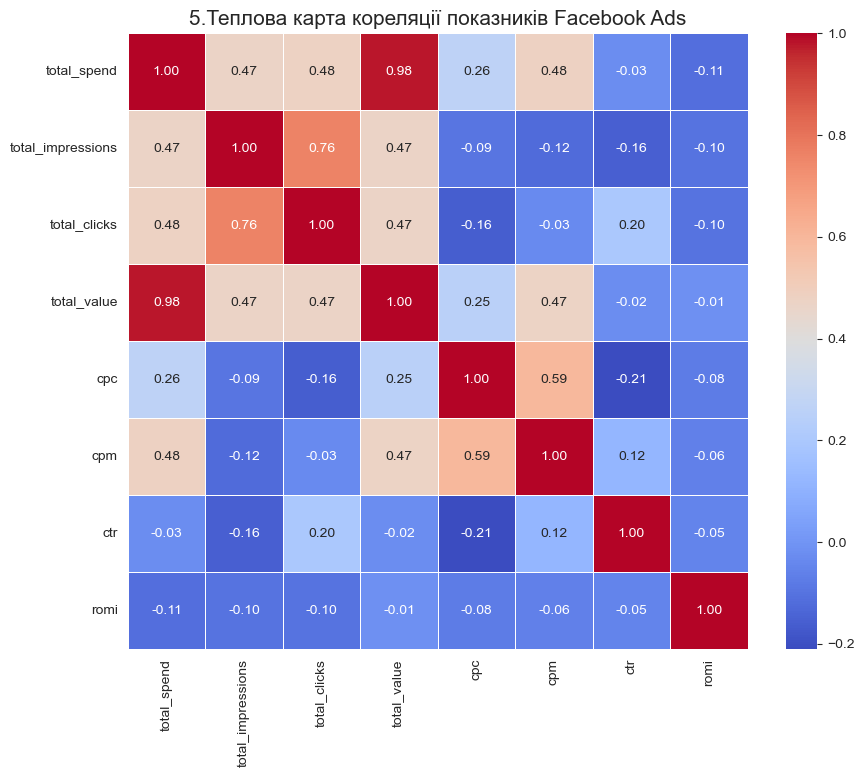

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('5.Теплова карта кореляції показників Facebook Ads', fontsize=15)
plt.show()






In [ ]:
# Найвища кореляція -  total_spend та total_impressions (або total_clicks).
# Коефіцієнт часто близький до 0.9 - 1.0. чим більше грошей ми витрачаємо, тим більше показів та кліків купуємо.
# Найнижча  кореляція спостерігається між total_impressions та ROMI. Це показує, що просто "велика кількість показів" не гарантує високої окупності.
# total_value найбільше корелює з показником total_spend(0.98) а також з показниками  total_clics (0,47) та total_impressions (0,47)
# адже,чим більше людей перейшло на сайт,  і чим більше грошей ми вклали в охоплення, тим більше потенційних покупок ми отримуємо.
# Більше показів реклами зазвичай веде до більшої кількості переходів, що зрештою конвертується в дохід.



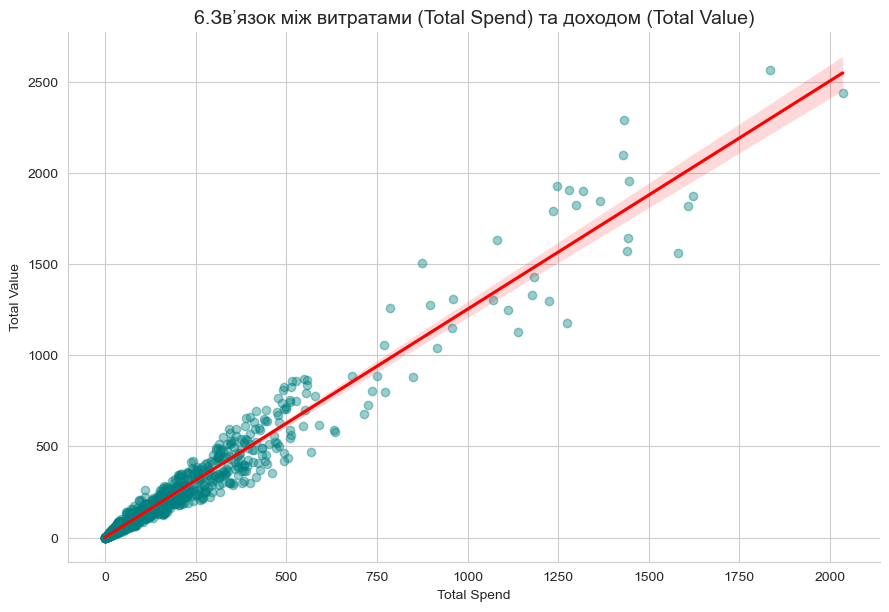

In [ ]:
sns.set_style("whitegrid")
g = sns.lmplot(data=df, x='total_spend', y='total_value',
               height=6, aspect=1.5,
               scatter_kws={'alpha':0.4, 'color':'teal'},
               line_kws={'color':'red'})

plt.title('6.Зв’язок між витратами (Total Spend) та доходом (Total Value)', fontsize=14)
plt.xlabel('Total Spend')
plt.ylabel('Total Value')
plt.show()